In [37]:
import pandas as pd
import os

# Obtener el directorio actual (donde está corriendo el notebook)
base_path = os.getcwd()

# Ruta completa al archivo
csv_path = os.path.join(base_path, 'Data', 'PV2D_FieldData_filtered.csv')

# Leer el CSV
df = pd.read_csv(csv_path)
df.head()

,Id,Data_ContainedType,Data_CountTotal,Data_Elements,Data_DimensionCount,Data_CountX,Data_CountY,Data_CountZ,Data_ReferenceX,Data_ReferenceY,...,GantryAngleCorrectionEnergy,IsIntegral,ModificationsIndex,ChangeHistory,IntegralGantryAnglesInfo,IsIsocenter,DistanceToIsocenter,IsocenterPosition,InPhantomRotation,IsExtractedPlane
0,BF6B0782-A9F7-4D89-B795-0005D3657170,System.Double,1024,b'\x00\x01\x00\x00\x00\xff\xff\xff\xff\x01\x00...,2,32,32,0,-118.0945,-118.0945,...,6,True,0,NaN,209.77 209.73 209.75 209.82 209.73 209.76 209....,False,0.0,NaN,0,False
1,8142949D-22C7-4A07-B111-001E83981DE0,System.Double,1024,b'\x00\x01\x00\x00\x00\xff\xff\xff\xff\x01\x00...,2,32,32,0,-118.0945,-118.0945,...,0,True,0,"3/1/2025 18:35 sbianchini: Rescale: 1,0150¥6/1...",NaN,False,0.0,NaN,0,False
2,EE8EA67C-FDD3-449A-922D-005AECC5F7C7,System.Double,1024,b'\x00\x01\x00\x00\x00\xff\xff\xff\xff\x01\x00...,2,32,32,0,-118.0945,-118.0945,...,0,True,0,NaN,179.82 179.82 179.82 179.81 179.82 179.81 179....,False,0.0,NaN,0,False
3,E9E3DBA7-6433-49AC-A636-00BB23F70159,System.Double,1024,b'\x00\x01\x00\x00\x00\xff\xff\xff\xff\x01\x00...,2,32,32,0,-118.0945,-118.0945,...,6,True,0,NaN,180.10 180.13 180.11 180.10 180.11 180.13 180....,False,0.0,NaN,0,False
4,867FC52E-04B2-469A-A62E-00C015B59F75,System.Double,1024,b'\x00\x01\x00\x00\x00\xff\xff\xff\xff\x01\x00...,2,32,32,0,-118.0945,-118.0945,...,6,True,0,NaN,179.94 179.94 179.97 179.95 179.95 179.97 179....,False,0.0,NaN,0,False


In [38]:
df.columns

Index(['Id', 'Data_ContainedType', 'Data_CountTotal', 'Data_Elements',
       'Data_DimensionCount', 'Data_CountX', 'Data_CountY', 'Data_CountZ',
       'Data_ReferenceX', 'Data_ReferenceY', 'Data_ReferenceZ',
       'Data_SpacingX', 'Data_SpacingY', 'Data_SpacingZ',
       'GantryAngleNullable', 'SignalTypeIndex', 'ReferenceRelativeValue',
       'PlaneTypeIndex', 'ImageTypeValue', 'CalculationTypeIndex',
       'ReferenceSignalImageId', 'CompareSignalImageId', 'ReferenceVersion',
       'CompareVersion', 'Version', 'MeasurementFrameId', 'MeasurementId',
       'IsDicom', 'BeamStatus', 'GantryAngleCorrectionTableName',
       'GantryAngleCorrectionBqi', 'GantryAngleCorrectionEnergy', 'IsIntegral',
       'ModificationsIndex', 'ChangeHistory', 'IntegralGantryAnglesInfo',
       'IsIsocenter', 'DistanceToIsocenter', 'IsocenterPosition',
       'InPhantomRotation', 'IsExtractedPlane'],
      dtype='object')

In [39]:
df['Data_SpacingX'].value_counts()

Data_SpacingX
7.619    592
1.000      1
Name: count, dtype: int64

E9E3DBA7-6433-49AC-A636-00BB23F70159


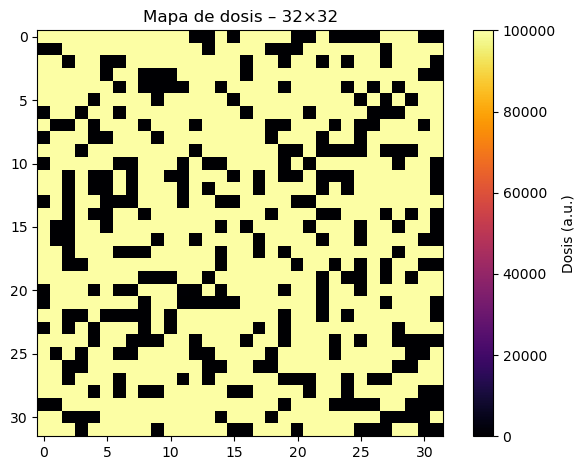

In [40]:
import numpy as np
import matplotlib.pyplot as plt

id = "E9E3DBA7-6433-49AC-A636-00BB23F70159"
byte_data = df[df["Id"] == id].Data_Elements.values[0]
# Convertimos el string ASCII a bytes
byte_data = byte_data.encode('latin1')  # o 'utf-8' si sabés que la codificación fue otra
print(df[df["Id"] == id].Id.values[0])
header_size = 32                         # bytes de encabezado fijo
rows = 32                                # según las columnas de la tabla
cols = 32

# --- 1. recortamos el encabezado ------------------------------------------
payload = byte_data[header_size : header_size + rows*cols*8]  # 8 bytes por double

# --- 2. interpretamos como float64 (System.Double) -------------------------
dose_flat = np.frombuffer(payload, dtype=np.float64)

#n_min=dose_flat.argmin()
#dose_flat_copia=dose_flat.copy()
#dose_flat_copia[n_min]=0

# --- 3. reshape ------------------------------------------------------------
dose_map = dose_flat.reshape((rows, cols))

# --- 4. visualizamos -------------------------------------------------------
vmin = np.percentile(dose_map, 1)
vmax = np.percentile(dose_map, 99)
plt.imshow(dose_map, cmap='inferno', vmin=0, vmax=100000)
plt.colorbar(label='Dosis (a.u.)')
plt.title(f"Mapa de dosis – {rows}×{cols}")
plt.tight_layout()
plt.show()


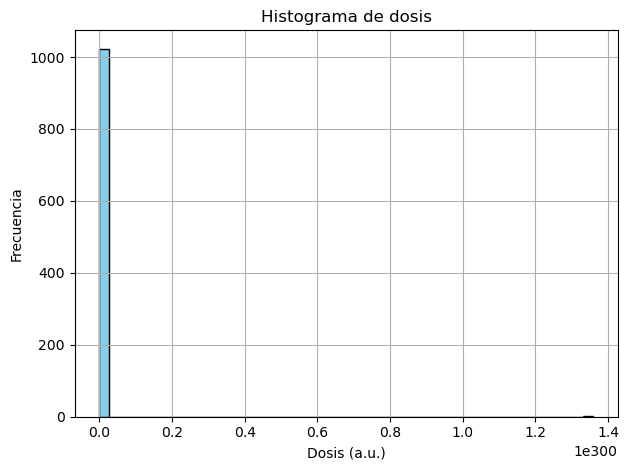

In [26]:
# Aplanar la matriz 2D en un vector 1D
valores = dose_map.ravel()

# ❷ Filtrar sólo los números finitos
valores_ok = valores[np.isfinite(valores)]

# Crear histograma
plt.hist(valores, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Dosis (a.u.)')
plt.ylabel('Frecuencia')
plt.title('Histograma de dosis')
plt.grid(True)
plt.tight_layout()
plt.show()

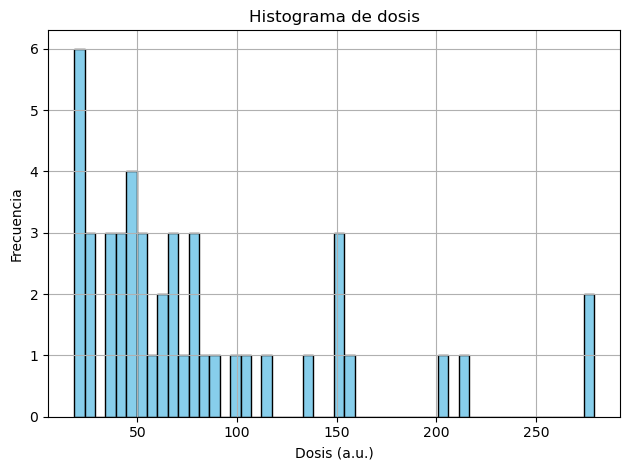

In [34]:
arr = np.array([5, 12, 7, 3, 20, 1])
umbral_bajo = 5
umbral_alto = 300

# Eliminar los mayores a 10
arr = dose_map.ravel()
filtrado = arr[(arr < umbral_alto) & (arr > umbral_bajo)]

# Crear histograma
plt.hist(filtrado, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Dosis (a.u.)')
plt.ylabel('Frecuencia')
plt.title('Histograma de dosis')
plt.grid(True)
plt.tight_layout()
plt.show()